# 데이터 파이프라인 완성

> 정제 + 형식 변환 + 오염 방지 + 분할을 **하나의 재현 가능한 파이프라인**으로 통합

In [1]:
# === 환경 설치 ===
!pip install datasets transformers scikit-learn matplotlib

In [2]:
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import numpy as np
import re
import json
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. 데이터 오염(Contamination) 체크

학습 데이터에 벤치마크 테스트셋이 섞여 들어가면 평가가 무의미해진다.  
n-gram 오버랩으로 오염을 탐지한다.

In [3]:
# === n-gram 오버랩 체크 ===
# 학습 데이터와 벤치마크 사이의 텍스트 겹침을 탐지

def extract_ngrams(text, n=8):
    """텍스트에서 연속 n개 단어(n-gram) 집합 추출"""
    words = text.lower().split()
    if len(words) < n:
        return set()
    return set(' '.join(words[i:i+n]) for i in range(len(words) - n + 1))

def check_contamination(train_texts, benchmark_texts, n=8, threshold=0.5):
    """
    학습 데이터와 벤치마크 데이터 사이의 n-gram 오버랩을 체크.
    
    threshold: 벤치마크 n-gram 중 이 비율 이상이 학습 데이터에 있으면 오염
    """
    # 학습 데이터의 모든 n-gram 수집
    train_ngrams = set()
    for text in train_texts:
        train_ngrams.update(extract_ngrams(text, n))
    
    # 각 벤치마크 샘플과 오버랩 체크
    contaminated = []
    for i, bench_text in enumerate(benchmark_texts):
        bench_ngrams = extract_ngrams(bench_text, n)
        if not bench_ngrams:
            continue
        overlap = bench_ngrams & train_ngrams
        overlap_ratio = len(overlap) / len(bench_ngrams)
        if overlap_ratio >= threshold:
            contaminated.append((i, overlap_ratio, bench_text[:60]))
    
    return contaminated, len(train_ngrams)

# 시뮬레이션: 학습 데이터와 벤치마크 데이터
train_texts = [
    "The capital of France is Paris which is known as the city of light and love",
    "Python is a programming language that supports multiple paradigms including OOP",
    "Machine learning is a subset of artificial intelligence that learns from data",
]

benchmark_texts = [
    "The capital of France is Paris which is known as the city of light and love",  # 완전 오염
    "What is the largest planet in our solar system Jupiter is the answer",  # 오염 없음
    "Python is a programming language that supports multiple paradigms including OOP and functional",  # 부분 오염
]

contaminated, total_ngrams = check_contamination(train_texts, benchmark_texts, n=8)

print(f"오염 체크 결과 (n=8):")
print(f"  학습 데이터 n-gram 수: {total_ngrams}")
print(f"  벤치마크 샘플 수: {len(benchmark_texts)}")
print(f"  오염 의심: {len(contaminated)}개")

for idx, ratio, preview in contaminated:
    print(f"\n  [{idx}] 오버랩: {ratio:.1%}")
    print(f"      {preview}...")

safe_count = len(benchmark_texts) - len(contaminated)
print(f"\n안전: {safe_count}개, 오염: {len(contaminated)}개")
print("-> 오염된 샘플은 학습 데이터에서 제거해야 함")

오염 체크 결과 (n=8):
  학습 데이터 n-gram 수: 18
  벤치마크 샘플 수: 3
  오염 의심: 2개

  [0] 오버랩: 100.0%
      The capital of France is Paris which is known as the city of...

  [2] 오버랩: 66.7%
      Python is a programming language that supports multiple para...

안전: 1개, 오염: 2개
-> 오염된 샘플은 학습 데이터에서 제거해야 함


---
## 2. Train / Validation / Test 분할

In [4]:
# === 데이터 분할: 학습 / 검증 / 테스트 ===
# 올바른 분할이 없으면 과적합을 감지할 수 없다

dataset = load_dataset("tatsu-lab/alpaca", trust_remote_code=True)
train_full = dataset['train']

# 실습용 1000개
data = train_full.shuffle(seed=42).select(range(1000))

# 80% train / 10% val / 10% test
train_val = data.train_test_split(test_size=0.2, seed=42)
val_test = train_val['test'].train_test_split(test_size=0.5, seed=42)

splits = DatasetDict({
    'train': train_val['train'],
    'validation': val_test['train'],
    'test': val_test['test'],
})

print("데이터 분할 결과:")
for split_name, split_data in splits.items():
    pct = len(split_data) / len(data) * 100
    print(f"  {split_name}: {len(split_data)}개 ({pct:.0f}%)")

print("\n각 분할의 역할:")
print("  train: 모델 학습에 사용")
print("  validation: 학습 중 과적합 감지 (epoch마다 체크)")
print("  test: 학습 완료 후 최종 성능 평가 (한 번만 사용)")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tatsu-lab/alpaca' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


데이터 분할 결과:
  train: 800개 (80%)
  validation: 100개 (10%)
  test: 100개 (10%)

각 분할의 역할:
  train: 모델 학습에 사용
  validation: 학습 중 과적합 감지 (epoch마다 체크)
  test: 학습 완료 후 최종 성능 평가 (한 번만 사용)


---
## 3. 전체 파이프라인 통합

01~03에서 배운 모든 과정을 하나의 파이프라인으로 합친다.

In [5]:
# === 전체 파이프라인 클래스 ===

class FinetuneDataPipeline:
    """
    파인튜닝 데이터 준비 전체 파이프라인.
    
    흐름:
    1. 데이터 로드
    2. 형식 검증
    3. 기초 필터링
    4. 유사도 중복 제거
    5. 형식 변환 (Chat Template)
    6. 분할 (Train/Val/Test)
    7. 통계 리포트
    """
    
    def __init__(self, min_output_len=30, max_output_len=5000, sim_threshold=0.85):
        self.min_output_len = min_output_len
        self.max_output_len = max_output_len
        self.sim_threshold = sim_threshold
        self.stats = {}  # 각 단계별 통계 기록
    
    def step1_validate(self, dataset):
        """형식 검증: 필수 필드 존재 여부"""
        valid = dataset.filter(
            lambda x: (x['instruction'] is not None and 
                       len(x['instruction'].strip()) > 0 and
                       x['output'] is not None and 
                       len(x['output'].strip()) > 0)
        )
        self.stats['after_validate'] = len(valid)
        return valid
    
    def step2_filter(self, dataset):
        """기초 필터링: 길이 기반"""
        filtered = dataset.filter(
            lambda x: self.min_output_len <= len(x['output']) <= self.max_output_len
        )
        self.stats['after_filter'] = len(filtered)
        return filtered
    
    def step3_dedup(self, dataset):
        """유사도 기반 중복 제거"""
        instructions = [dataset[i]['instruction'] for i in range(len(dataset))]
        
        vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
        tfidf = vectorizer.fit_transform(instructions)
        sim = cosine_similarity(tfidf)
        
        to_remove = set()
        for i in range(len(sim)):
            for j in range(i + 1, len(sim)):
                if sim[i][j] >= self.sim_threshold and i not in to_remove:
                    to_remove.add(j)
        
        to_keep = [i for i in range(len(dataset)) if i not in to_remove]
        deduped = dataset.select(to_keep)
        self.stats['after_dedup'] = len(deduped)
        self.stats['duplicates_removed'] = len(to_remove)
        return deduped
    
    def step4_convert(self, dataset, format_type='chatml'):
        """Chat Template 변환"""
        def to_chatml(sample):
            if sample.get('input') and sample['input'].strip():
                user_msg = f"{sample['instruction']}\n\nInput: {sample['input']}"
            else:
                user_msg = sample['instruction']
            
            text = f"<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n{sample['output']}<|im_end|>"
            return {"text": text}
        
        converted = dataset.map(to_chatml)
        self.stats['format'] = format_type
        return converted
    
    def step5_split(self, dataset, test_size=0.1, val_size=0.1, seed=42):
        """Train/Val/Test 분할"""
        total_test = test_size + val_size
        train_rest = dataset.train_test_split(test_size=total_test, seed=seed)
        val_ratio = val_size / total_test
        val_test = train_rest['test'].train_test_split(test_size=val_ratio, seed=seed)
        
        result = DatasetDict({
            'train': train_rest['train'],
            'validation': val_test['train'],
            'test': val_test['test'],
        })
        
        for k, v in result.items():
            self.stats[f'split_{k}'] = len(v)
        
        return result
    
    def run(self, dataset, format_type='chatml'):
        """전체 파이프라인 실행"""
        self.stats['original'] = len(dataset)
        print(f"원본: {len(dataset)}개")
        
        dataset = self.step1_validate(dataset)
        print(f"  1. 형식 검증 후: {len(dataset)}개")
        
        dataset = self.step2_filter(dataset)
        print(f"  2. 길이 필터 후: {len(dataset)}개")
        
        dataset = self.step3_dedup(dataset)
        dup_count = self.stats.get('duplicates_removed', 0)
        print(f"  3. 중복 제거 후: {len(dataset)}개 (유사 중복 {dup_count}개 제거)")
        
        dataset = self.step4_convert(dataset, format_type)
        print(f"  4. {format_type} 형식 변환 완료")
        
        splits = self.step5_split(dataset)
        print(f"  5. 분할 완료:")
        for k, v in splits.items():
            print(f"     {k}: {len(v)}개")
        
        return splits

# 파이프라인 실행
print("=" * 60)
print("파이프라인 실행")
print("=" * 60)

pipeline = FinetuneDataPipeline(
    min_output_len=30,
    max_output_len=5000,
    sim_threshold=0.85,
)

# 실습용 1000개
raw_data = train_full.shuffle(seed=42).select(range(1000))
final_splits = pipeline.run(raw_data, format_type='chatml')

파이프라인 실행
원본: 1000개


Filter: 100%|██████████| 1000/1000 [00:00<00:00, 28947.40 examples/s]


  1. 형식 검증 후: 1000개


Filter: 100%|██████████| 1000/1000 [00:00<00:00, 38752.54 examples/s]

  2. 길이 필터 후: 870개


  3. 중복 제거 후: 870개 (유사 중복 0개 제거)


Map: 100%|██████████| 870/870 [00:00<00:00, 15446.02 examples/s]


  4. chatml 형식 변환 완료
  5. 분할 완료:
     train: 696개
     validation: 87개
     test: 87개


In [6]:
# === 최종 데이터 확인 ===

print("최종 train 데이터 샘플:")
print("=" * 60)
sample = final_splits['train'][0]
print(sample['text'][:300])
print("...")

print(f"\n-> 이 형식이 Phase 4 SFTTrainer에 바로 입력됨")

최종 train 데이터 샘플:
<|im_start|>user
Outline the range of colors a television can display.<|im_end|>
<|im_start|>assistant
Most modern televisions are able to display a range of colors, with 16.7 million colors being the maximum number of colors supported by the average television. This means that the television is abl
...

-> 이 형식이 Phase 4 SFTTrainer에 바로 입력됨


---
## 4. 데이터 카드 생성

In [7]:
# === 데이터 카드: 파이프라인 결과 메타데이터 ===
# 나중에 재현하거나 공유할 때 필수

tokenizer = AutoTokenizer.from_pretrained('gpt2')

# 토큰 길이 통계 (train 데이터)
train_data = final_splits['train']
token_lengths = []
for i in range(min(200, len(train_data))):
    tokens = tokenizer.encode(train_data[i]['text'])
    token_lengths.append(len(tokens))

data_card = {
    "source": "tatsu-lab/alpaca",
    "original_size": pipeline.stats['original'],
    "final_size": {
        "train": pipeline.stats.get('split_train', 0),
        "validation": pipeline.stats.get('split_validation', 0),
        "test": pipeline.stats.get('split_test', 0),
    },
    "format": pipeline.stats.get('format', 'chatml'),
    "filtering": {
        "min_output_len": pipeline.min_output_len,
        "max_output_len": pipeline.max_output_len,
        "similarity_threshold": pipeline.sim_threshold,
        "duplicates_removed": pipeline.stats.get('duplicates_removed', 0),
    },
    "token_stats": {
        "mean": int(np.mean(token_lengths)),
        "median": int(np.median(token_lengths)),
        "max": int(np.max(token_lengths)),
        "min": int(np.min(token_lengths)),
    },
    "retention_rate": f"{sum(v for v in pipeline.stats.get('split_train', 0).__class__.__mro__[:0]) or (pipeline.stats.get('split_train', 0) + pipeline.stats.get('split_validation', 0) + pipeline.stats.get('split_test', 0)) / pipeline.stats['original'] * 100:.1f}%",
}

# 유지율 직접 계산
total_final = (pipeline.stats.get('split_train', 0) + 
               pipeline.stats.get('split_validation', 0) + 
               pipeline.stats.get('split_test', 0))
retention = total_final / pipeline.stats['original'] * 100
data_card['retention_rate'] = f"{retention:.1f}%"

print("데이터 카드:")
print("=" * 60)
print(json.dumps(data_card, indent=2, ensure_ascii=False))

print(f"\n-> 이 데이터 카드를 저장해두면:")
print(f"   1. 파이프라인 재현 가능")
print(f"   2. Phase 4에서 max_seq_length 설정 근거")
print(f"   3. 실험 비교 시 데이터 조건 기록")

데이터 카드:
{
  "source": "tatsu-lab/alpaca",
  "original_size": 1000,
  "final_size": {
    "train": 696,
    "validation": 87,
    "test": 87
  },
  "format": "chatml",
  "filtering": {
    "min_output_len": 30,
    "max_output_len": 5000,
    "similarity_threshold": 0.85,
    "duplicates_removed": 0
  },
  "token_stats": {
    "mean": 110,
    "median": 103,
    "max": 272,
    "min": 46
  },
  "retention_rate": "87.0%"
}

-> 이 데이터 카드를 저장해두면:
   1. 파이프라인 재현 가능
   2. Phase 4에서 max_seq_length 설정 근거
   3. 실험 비교 시 데이터 조건 기록


---
## 5. 최종 시각화

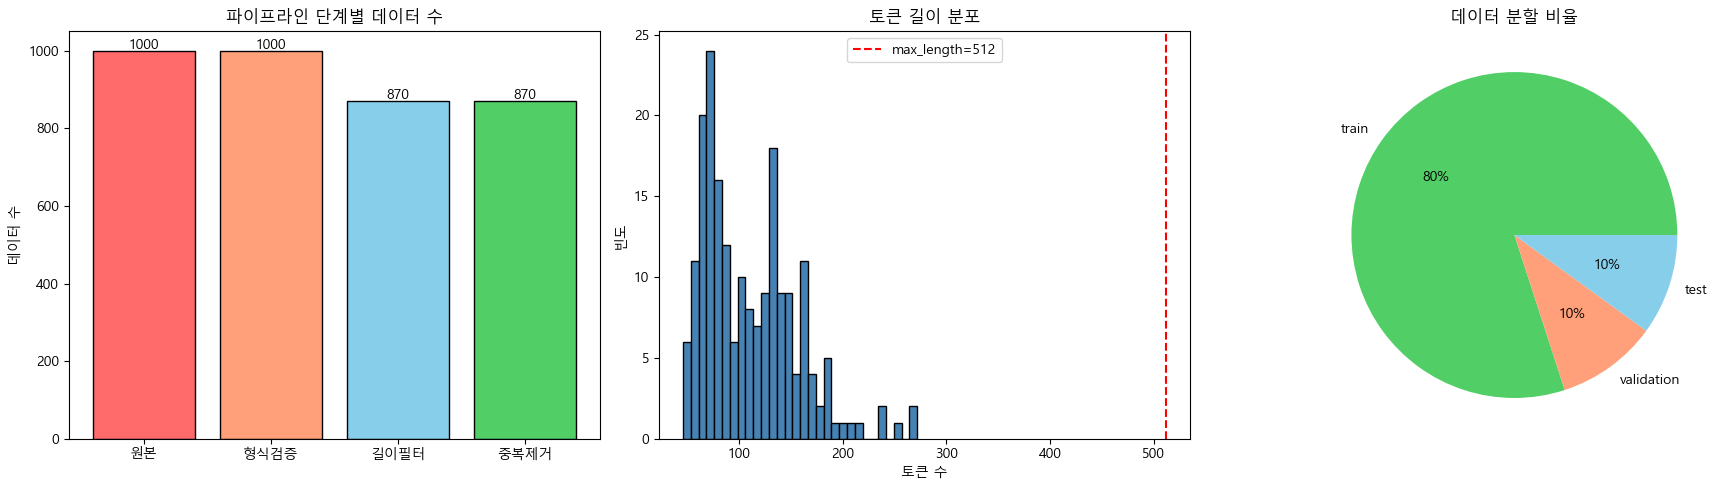

In [8]:
# === 파이프라인 전체 결과 시각화 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 파이프라인 단계별 데이터 수
stages = ['원본', '형식검증', '길이필터', '중복제거']
counts = [
    pipeline.stats['original'],
    pipeline.stats.get('after_validate', 0),
    pipeline.stats.get('after_filter', 0),
    pipeline.stats.get('after_dedup', 0),
]
colors = ['#ff6b6b', '#ffa07a', '#87ceeb', '#51cf66']
axes[0].bar(stages, counts, color=colors, edgecolor='black')
axes[0].set_title('파이프라인 단계별 데이터 수')
axes[0].set_ylabel('데이터 수')
for i, c in enumerate(counts):
    axes[0].text(i, c + 5, str(c), ha='center')

# 2) 토큰 길이 분포
axes[1].hist(token_lengths, bins=30, edgecolor='black', color='steelblue')
axes[1].axvline(x=512, color='r', linestyle='--', label='max_length=512')
axes[1].set_xlabel('토큰 수')
axes[1].set_ylabel('빈도')
axes[1].set_title('토큰 길이 분포')
axes[1].legend()

# 3) 분할 비율
split_names = list(final_splits.keys())
split_sizes = [len(final_splits[k]) for k in split_names]
axes[2].pie(split_sizes, labels=split_names, autopct='%1.0f%%',
           colors=['#51cf66', '#ffa07a', '#87ceeb'])
axes[2].set_title('데이터 분할 비율')

plt.tight_layout()
plt.show()

---
## Phase 3 전체 정리

| # | 내용 | 핵심 |
|---|------|------|
| 01 | Chat Template & 형식 변환 | 모델별 형식, Alpaca→ChatML 변환 |
| 02 | 고급 데이터 정제 | TF-IDF 중복제거, 품질 스코어 |
| 03 | 합성 데이터 생성 | Self-Instruct, Evol-Instruct |
| 04 | 파이프라인 완성 | 오염 방지, 분할, 통합 파이프라인 |

### 다음: Phase 4 (LoRA/QLoRA 파인튜닝)

Phase 3에서 만든 데이터를 가지고:
- LoRA/QLoRA 이론 학습
- Llama/Qwen 모델 실제 파인튜닝
- 학습 결과 평가